# Tutorial 5 : Identifying rare cell types

Mounting google drive to accessing input data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install diptest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from diptest import diptest

Criteria 1: Bottom 10% in terms of CTP

In [ ]:
def get_rare(ctp_path, per):
    dt = pd.read_csv(ctp_path)
    celltypes = dt.columns[1:].values
    print (celltypes, len(celltypes), "\n")
    dt = dt[celltypes]
    dt = dt.mean()
    rare = dt.sort_values()[: round(per*len(dt))]
    return rare

In [ ]:

path = "/content/drive/MyDrive/Major_project/Benchmarking_Shared/spDDB_tutorials/4_data/"

rare = get_rare(path + "Simulated_cell_type_proportion_DLPFC_151508.csv", 0.1)
print (rare)

['AST_FB' 'AST_PP' 'Endothelial' 'IN_PV' 'IN_SST' 'IN_SV2C' 'IN_VIP'
 'L2_3' 'L4' 'L5_6' 'L5_6_CC' 'Microglia' 'Neu_NRGN_I' 'Neu_NRGN_II'
 'Neu_mat' 'OPC' 'Oligodendrocytes'] 17 

OPC          0.034814
Microglia    0.036579
dtype: float64


Identifying Regional Rare cell types

In [ ]:
def bi_modal(data):
    # Sample data
    #data = np.random.normal(0, 1, 500).tolist() + np.random.normal(5, 1, 500).tolist()

    # Convert list to NumPy array
    data = np.array(data)
    # Statistical Test: Dip Test
    dip_stat, p_value = diptest(data)
    print(f"Dip Statistic: {dip_stat}, p-value: {p_value}")

    # Interpretation
    if p_value < 0.05:
        print("The data is likely bimodal (reject the null hypothesis of unimodality).")
        return True
    else:
        print("The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).")
        return False

def binned_data(ctp_path, bottom_50):

    df = pd.read_csv(ctp_path)

    bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    dt = pd.DataFrame({
    'Range': ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
    })

    plt.figure(figsize=(12, 8))

    new_cols = [df.columns[0]] + bottom_50.tolist()
    print (new_cols)

    df = df[new_cols]

    for column in df.columns[1:]:
        sns.kdeplot(df[column], label=column, bw_adjust=0.5)

    plt.title('KDE Plots')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend(title='Columns')
    plt.show()

    cell_type = []


    for c in df.columns[1:]:
        print (c, "\n")
        flag = bi_modal(df[c])
        if (flag):
            cell_type += [c]


    binned_ct = {}
    for c in df.columns[1:]:

        binned_ct[c] = pd.cut(df[c], bins = bins)
        dt[c + "_count"] = binned_ct[c].value_counts(sort = False).values

    print (cell_type)
    cell_type = [element + "_count" for element in cell_type]
    dt = dt.T


    return (dt[dt.index.isin(cell_type)], dt)


['AST_FB' 'AST_PP' 'Endothelial' 'IN_PV' 'IN_SST' 'IN_SV2C' 'IN_VIP'
 'L2_3' 'L4' 'L5_6' 'L5_6_CC' 'Microglia' 'Neu_NRGN_I' 'Neu_NRGN_II'
 'Neu_mat' 'OPC' 'Oligodendrocytes'] 17 

['OPC' 'Microglia' 'IN_SV2C' 'L5_6_CC' 'IN_PV']
['Unnamed: 0', 'OPC', 'Microglia', 'IN_SV2C', 'L5_6_CC', 'IN_PV']


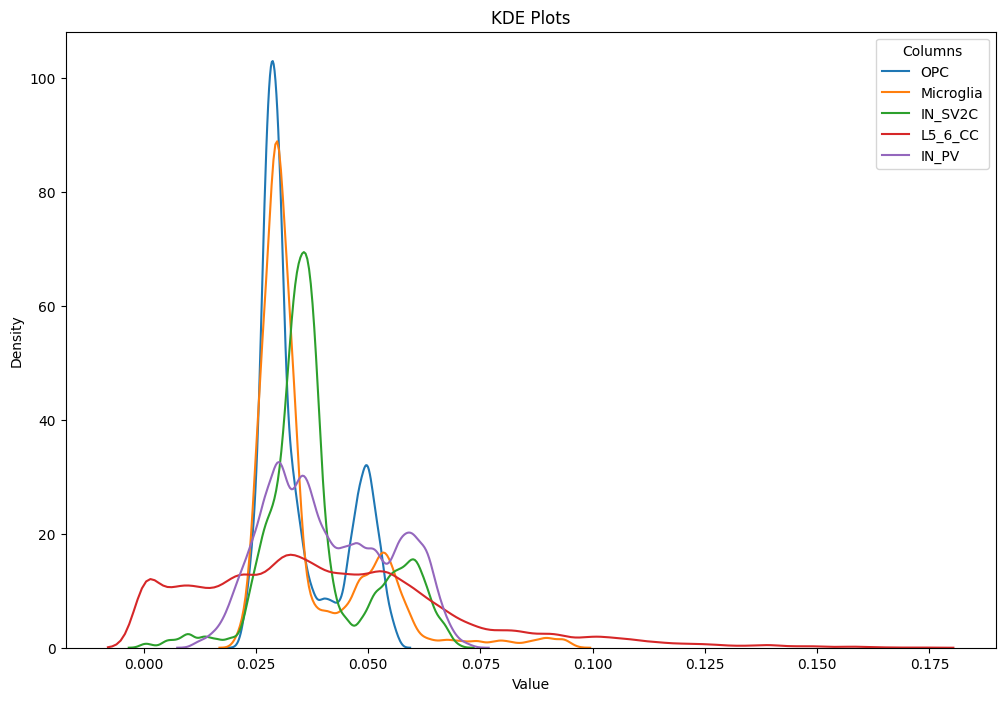

OPC 

Dip Statistic: 0.03641614353585341, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
Microglia 

Dip Statistic: 0.02007303742314859, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_SV2C 

Dip Statistic: 0.0198610036445067, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
L5_6_CC 

Dip Statistic: 0.021958265457792503, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_PV 

Dip Statistic: 0.007874752632888343, p-value: 0.07279275480181857
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
['OPC', 'Microglia', 'IN_SV2C', 'L5_6_CC']
                    0    1  2  3  4  5  6  7  8
OPC_count        4382    0  0  0  0  0  0  0  0
Microglia_count  4382    0  0  0  0  0  0  0  0
IN_SV2C_count    4378    0  0  0  0  0  0  0  0
L5_6_CC_count    4008  182  0  0  0  0  0  0  0


In [ ]:
lst = {
        "Brain" : ["151508"], #"151509", "151669", "151670", "151673", "151674"
      "Cancer": [],
      "Development" : []
    }

for l in lst["Brain"]:

    ctp_path = path + "Simulated_cell_type_proportion_DLPFC_151508.csv"

    rare = get_rare(ctp_path, 0.3)

    bottom_50 = rare.index.values

    print (bottom_50)


    dt, dt_unfil = binned_data(ctp_path, bottom_50)

    print (dt)